# Model Comparison: GARCH vs EGARCH-X vs LGBM
### Stock 1: DATA3888 Group 8

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

# ── Paths ─────────────────────────────────────────────────────────────────────
GARCH_CSV   = r"m4_outputs/garch_eval_results.csv"
EGARCHX_CSV = r"m4_outputs/egarchx_eval_results.csv"
LGBM_CSV    = r"lgbm_outputs/lgbm_eval_results.csv"

STOCK_ID = 1   # change here to compare a different stock (GARCH/EGARCHX are fixed to stock 1)

# ── Load ──────────────────────────────────────────────────────────────────────
garch   = pd.read_csv(GARCH_CSV)
egarchx = pd.read_csv(EGARCHX_CSV)
lgbm    = pd.read_csv(LGBM_CSV)
lgbm_s  = lgbm[lgbm["stock_id"] == STOCK_ID].copy()

print(f"GARCH   time_ids : {garch['time_id'].nunique()}")
print(f"EGARCHX time_ids : {egarchx['time_id'].nunique()}")
print(f"LGBM    time_ids : {lgbm_s['time_id'].nunique()}  (stock {STOCK_ID})")

GARCH   time_ids : 2789
EGARCHX time_ids : 2350
LGBM    time_ids : 3819  (stock 1)


## 1. Build per-time_id comparison table
Average the 4 validation bucket actuals so all three models are evaluated on the same target.

In [2]:
def qlike(pred, actual):
    pred   = np.maximum(np.asarray(pred,   float), 1e-10)
    actual = np.maximum(np.asarray(actual, float), 1e-10)
    return np.log(pred ** 2) + actual ** 2 / pred ** 2

def aggregate_to_timeid(df, pred_col):
    """Average 4 bucket actuals per time_id, recompute QLIKE and MSE on the mean."""
    agg = (df.groupby("time_id")
             .agg(pred=       (pred_col, "first"),
                  mean_actual=("actual",  "mean"))
             .reset_index())
    agg["QLIKE"] = qlike(agg["pred"].values, agg["mean_actual"].values)
    agg["MSE"]   = (agg["pred"] - agg["mean_actual"]) ** 2
    return agg

g_agg = aggregate_to_timeid(garch,   "pred_RV")
e_agg = aggregate_to_timeid(egarchx, "pred_RV")

# Common time_ids across all three
common = sorted(set(g_agg.time_id) & set(e_agg.time_id) & set(lgbm_s.time_id))
print(f"Common time_ids (all 3 models): {len(common)}")

g1 = g_agg[g_agg.time_id.isin(common)].set_index("time_id")
e1 = e_agg[e_agg.time_id.isin(common)].set_index("time_id")
l1 = lgbm_s[lgbm_s.time_id.isin(common)].set_index("time_id")

comp = pd.DataFrame({
    "GARCH_pred"    : g1.loc[common, "pred"].values,
    "EGARCHX_pred"  : e1.loc[common, "pred"].values,
    "LGBM_pred"     : l1.loc[common, "pred_vol"].values,
    "actual"        : l1.loc[common, "target_vol"].values,   # same as g1/e1 mean_actual
    "GARCH_QLIKE"   : g1.loc[common, "QLIKE"].values,
    "EGARCHX_QLIKE" : e1.loc[common, "QLIKE"].values,
    "LGBM_QLIKE"    : l1.loc[common, "QLIKE"].values,
    "GARCH_MSE"     : g1.loc[common, "MSE"].values,
    "EGARCHX_MSE"   : e1.loc[common, "MSE"].values,
    "LGBM_MSE"      : l1.loc[common, "MSE"].values,
}, index=common)
comp.index.name = "time_id"

comp.head(10)

Common time_ids (all 3 models): 1729


,GARCH_pred,EGARCHX_pred,LGBM_pred,actual,GARCH_QLIKE,EGARCHX_QLIKE,LGBM_QLIKE,GARCH_MSE,EGARCHX_MSE,LGBM_MSE
time_id,,,,,,,,,,
62,0.003190,0.011543,0.000581,0.000479,-11.472690,-8.921649,-14.220240,0.000007,1.224007e-04,1.041171e-08
103,0.008287,0.007176,0.001421,0.001753,-9.543308,-9.816762,-11.590634,0.000043,2.982465e-05,1.104492e-07
109,0.003257,0.001256,0.000597,0.000565,-11.423568,-13.156069,-13.950239,0.000007,4.749970e-07,9.969266e-10
128,0.005195,0.004855,0.000773,0.000805,-10.494364,-10.625876,-13.246717,0.000019,1.616765e-05,9.935137e-10
152,0.006622,0.006409,0.001032,0.000665,-10.024431,-10.089267,-13.337905,0.000035,3.293697e-05,1.345012e-07
159,0.003012,0.001369,0.000575,0.000643,-11.564951,-12.968276,-13.672763,0.000006,5.310213e-07,4.594507e-09
207,0.011153,0.002829,0.001820,0.002177,-8.954074,-11.143466,-11.187557,0.000081,4.255032e-07,1.270125e-07
211,0.003202,0.020194,0.000530,0.000560,-11.456844,-7.803966,-13.969069,0.000007,3.851966e-04,9.131262e-10
218,0.002492,0.002188,0.000437,0.000385,-11.965713,-12.218593,-14.694123,0.000004,3.262405e-06,2.717751e-09


## 2. Summary statistics

In [3]:
summary = pd.DataFrame({
    "Model"       : ["GARCH", "EGARCHX", "LGBM"],
    "Mean QLIKE"  : [comp["GARCH_QLIKE"].mean(),   comp["EGARCHX_QLIKE"].mean(),   comp["LGBM_QLIKE"].mean()],
    "Median QLIKE": [comp["GARCH_QLIKE"].median(), comp["EGARCHX_QLIKE"].median(), comp["LGBM_QLIKE"].median()],
    "Mean MSE"    : [comp["GARCH_MSE"].mean(),      comp["EGARCHX_MSE"].mean(),     comp["LGBM_MSE"].mean()],
    "Median MSE"  : [comp["GARCH_MSE"].median(),    comp["EGARCHX_MSE"].median(),   comp["LGBM_MSE"].median()],
    "n time_ids"  : [len(comp)] * 3,
})
summary.set_index("Model", inplace=True)
summary

,Mean QLIKE,Median QLIKE,Mean MSE,Median MSE,n time_ids
Model,,,,,
GARCH,-10.719230,-10.851199,3.355737e-05,1.298702e-05,1729
EGARCHX,-10.664178,-10.832079,7.970716e-05,1.078662e-05,1729
LGBM,-13.192073,-13.301698,7.511539e-08,1.540453e-08,1729


## 3. QLIKE distribution — boxplot

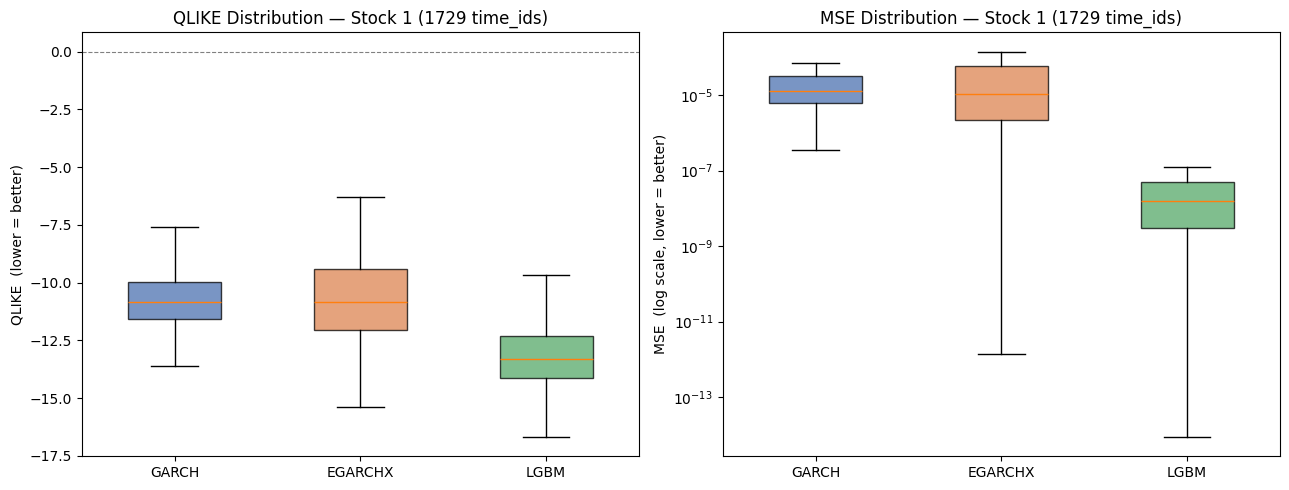

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ["#4C72B0", "#DD8452", "#55A868"]

# QLIKE boxplot
data_q = [comp["GARCH_QLIKE"], comp["EGARCHX_QLIKE"], comp["LGBM_QLIKE"]]
bp = axes[0].boxplot(data_q, patch_artist=True, showfliers=False, widths=0.5)
for patch, c in zip(bp["boxes"], colors):
    patch.set_facecolor(c); patch.set_alpha(0.75)
axes[0].set_xticklabels(["GARCH", "EGARCHX", "LGBM"])
axes[0].set_ylabel("QLIKE  (lower = better)")
axes[0].set_title(f"QLIKE Distribution — Stock {STOCK_ID} ({len(comp)} time_ids)")
axes[0].axhline(0, color="grey", linewidth=0.8, linestyle="--")

# MSE boxplot (log scale)
data_m = [comp["GARCH_MSE"], comp["EGARCHX_MSE"], comp["LGBM_MSE"]]
bp2 = axes[1].boxplot(data_m, patch_artist=True, showfliers=False, widths=0.5)
for patch, c in zip(bp2["boxes"], colors):
    patch.set_facecolor(c); patch.set_alpha(0.75)
axes[1].set_xticklabels(["GARCH", "EGARCHX", "LGBM"])
axes[1].set_yscale("log")
axes[1].set_ylabel("MSE  (log scale, lower = better)")
axes[1].set_title(f"MSE Distribution — Stock {STOCK_ID} ({len(comp)} time_ids)")

plt.tight_layout()
plt.savefig("lgbm_outputs/comparison_boxplot.png", dpi=150)
plt.show()

## 4. Predicted vs Actual — scatter per model

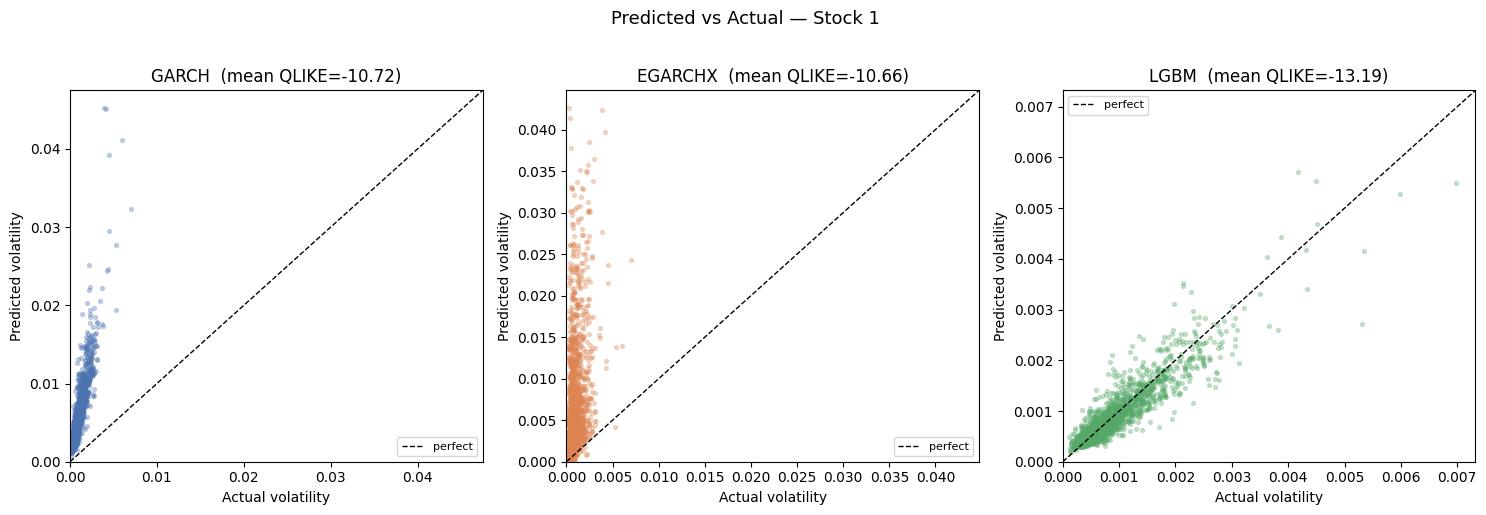

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

models = [
    ("GARCH",   "GARCH_pred",   colors[0]),
    ("EGARCHX", "EGARCHX_pred", colors[1]),
    ("LGBM",    "LGBM_pred",    colors[2]),
]

for ax, (name, pred_col, c) in zip(axes, models):
    ax.scatter(comp["actual"], comp[pred_col], alpha=0.3, s=8, color=c)
    lim = max(comp["actual"].max(), comp[pred_col].max()) * 1.05
    ax.plot([0, lim], [0, lim], "k--", linewidth=1, label="perfect")
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_xlabel("Actual volatility")
    ax.set_ylabel("Predicted volatility")
    ax.set_title(f"{name}  (mean QLIKE={comp[f'{name}_QLIKE'].mean():.2f})")
    ax.legend(fontsize=8)

plt.suptitle(f"Predicted vs Actual — Stock {STOCK_ID}", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("lgbm_outputs/comparison_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. QLIKE over time — line chart

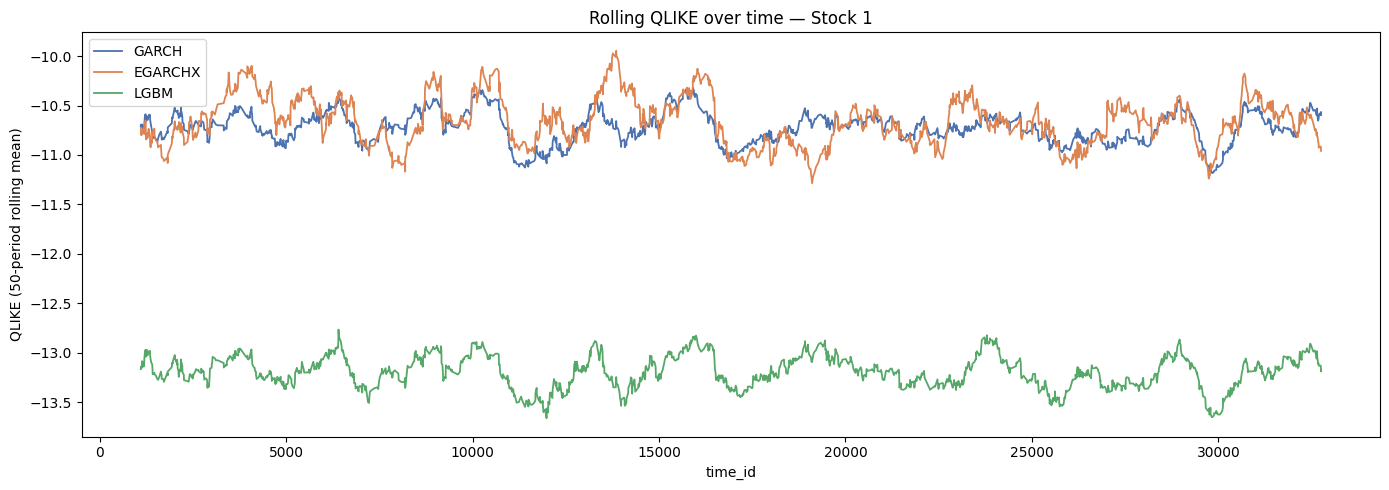

In [6]:
WINDOW = 50   # rolling window size

fig, ax = plt.subplots(figsize=(14, 5))

for name, col, c in [("GARCH", "GARCH_QLIKE", colors[0]),
                      ("EGARCHX", "EGARCHX_QLIKE", colors[1]),
                      ("LGBM", "LGBM_QLIKE", colors[2])]:
    rolled = comp[col].rolling(WINDOW).mean()
    ax.plot(comp.index, rolled, label=name, color=c, linewidth=1.3)

ax.set_xlabel("time_id")
ax.set_ylabel(f"QLIKE ({WINDOW}-period rolling mean)")
ax.set_title(f"Rolling QLIKE over time — Stock {STOCK_ID}")
ax.legend()
plt.tight_layout()
plt.savefig("lgbm_outputs/comparison_rolling_qlike.png", dpi=150)
plt.show()

## 6. Win rate — how often each model has the best QLIKE per time_id

Win rate (lowest QLIKE per time_id):
  LGBM      : 1684 / 1729  (97.4%)
  EGARCHX   :   38 / 1729  (2.2%)
  GARCH     :    7 / 1729  (0.4%)


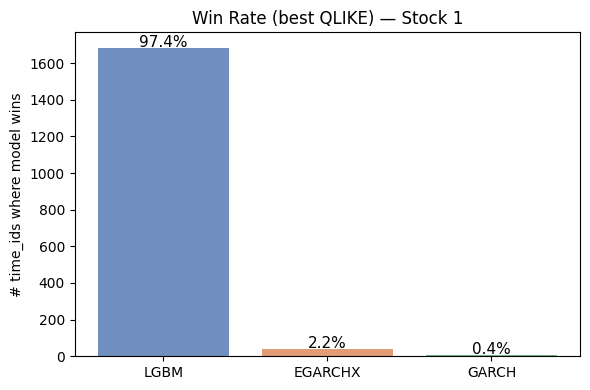

In [7]:
best = comp[["GARCH_QLIKE","EGARCHX_QLIKE","LGBM_QLIKE"]].idxmin(axis=1)
wins = best.value_counts().rename({"GARCH_QLIKE":"GARCH","EGARCHX_QLIKE":"EGARCHX","LGBM_QLIKE":"LGBM"})
pct  = (wins / len(comp) * 100).round(1)

print("Win rate (lowest QLIKE per time_id):")
for model, w, p in zip(wins.index, wins.values, pct.values):
    print(f"  {model:10s}: {w:4d} / {len(comp)}  ({p}%)")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(wins.index, wins.values, color=colors, alpha=0.8)
for i, (w, p) in enumerate(zip(wins.values, pct.values)):
    ax.text(i, w + 5, f"{p}%", ha="center", fontsize=11)
ax.set_ylabel("# time_ids where model wins")
ax.set_title(f"Win Rate (best QLIKE) — Stock {STOCK_ID}")
plt.tight_layout()
plt.savefig("lgbm_outputs/comparison_winrate.png", dpi=150)
plt.show()

## 7. Export full comparison table

In [14]:
out_path = f"lgbm_outputs/stock{STOCK_ID}_model_comparison.csv"
comp.reset_index().to_csv(out_path, index=False)
print(f"Saved: {out_path}  ({len(comp)} rows)")

Saved: lgbm_outputs/stock1_model_comparison.csv  (1729 rows)


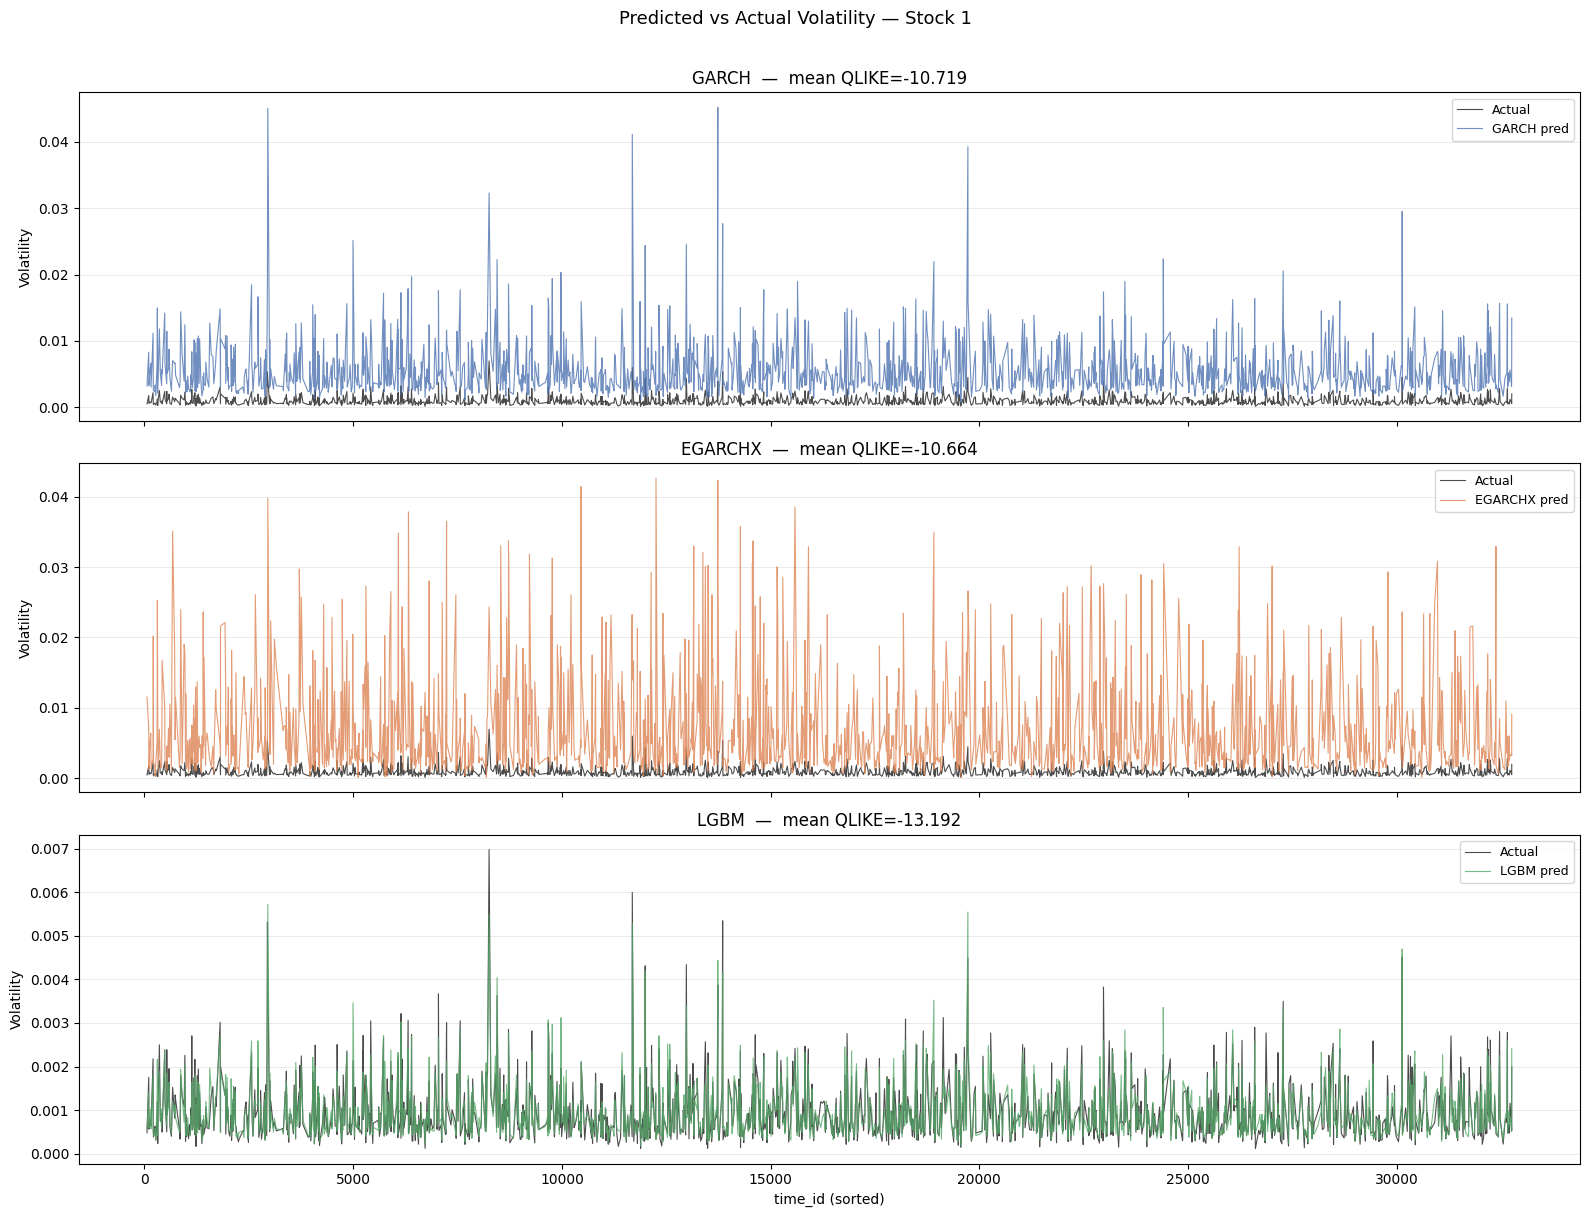

In [15]:
plot_df = comp.sort_index().reset_index()   # sort by time_id ascending

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

model_cfg = [
    ("GARCH",   "GARCH_pred",   colors[0]),
    ("EGARCHX", "EGARCHX_pred", colors[1]),
    ("LGBM",    "LGBM_pred",    colors[2]),
]

for ax, (name, pred_col, c) in zip(axes, model_cfg):
    ax.plot(plot_df["time_id"], plot_df["actual"],   color="black",  linewidth=0.8,
            alpha=0.7, label="Actual", zorder=2)
    ax.plot(plot_df["time_id"], plot_df[pred_col],   color=c,        linewidth=0.8,
            alpha=0.8, label=f"{name} pred", zorder=3)
    ax.set_ylabel("Volatility")
    ax.set_title(f"{name}  —  mean QLIKE={comp[f'{name}_QLIKE'].mean():.3f}")
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(axis="y", linewidth=0.4, alpha=0.5)

axes[-1].set_xlabel("time_id (sorted)")
plt.suptitle(f"Predicted vs Actual Volatility — Stock {STOCK_ID}", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("lgbm_outputs/comparison_line_pred_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()